In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')
print("Libraries imported!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...


Libraries imported!


In [3]:
fake = pd.read_csv('../dataset/Fake.csv')
real = pd.read_csv('../dataset/True.csv')
fake['label'] = 0 # 0 = Fake
real['label'] = 1 # 1 = Real
df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset loaded!")
print(f"Total : {len(df):,}")
print(f"Fake : {len(df[df['label']==0]):,}")
print(f"Real : {len(df[df['label']==1]):,}")
print(f"Columns : {df.columns.tolist()}")

Dataset loaded!
Total : 44,898
Fake : 23,481
Real : 21,417
Columns : ['title', 'text', 'subject', 'date', 'label']


In [4]:
print("=== First 3 rows ===")
print(df.head(3))
print("\n=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== First 3 rows ===
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label

In [5]:
print("Missing values before cleaning:")
print(df.isnull().sum())
df.dropna(subset=['text', 'title'], inplace=True)
df = df[df['text'].str.strip() != '']
df = df[df['title'].str.strip() != '']

Missing values before cleaning:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [6]:
df.reset_index(drop=True, inplace=True)
print(f"\nMissing values handled!")
print(f"Dataset size after cleaning: {len(df):,}")



Missing values handled!
Dataset size after cleaning: 44,267


In [7]:
df['combined'] = df['title'] + ' ' + df['text']
print("Title and text combined!")
print("\nExample (first 300 chars):")
print(df['combined'][0][:300])

Title and text combined!

Example (first 300 chars):
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements 


In [9]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print("Preprocessing function defined!")

Preprocessing function defined!


In [10]:
print("Preprocessing text... please wait...")
df['clean_text'] = df['combined'].apply(preprocess_text)
print("Preprocessing complete!")
print(f"\nOriginal:\n{df['combined'][0][:200]}")
print(f"\nCleaned:\n{df['clean_text'][0][:200]}")


Preprocessing text... please wait...
Preprocessing complete!

Original:
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame

Cleaned:
ben stein call th circuit court committed coup dtat constitution st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day m


In [11]:
df['word_count'] = df['clean_text'].apply(
lambda x: len(x.split()))
print("=== Word Count Stats ===")
print(df['word_count'].describe())
df = df[df['word_count'] >= 10]
df.reset_index(drop=True, inplace=True)
print(f"\nShort articles removed!")
print(f"Final size: {len(df):,}")

=== Word Count Stats ===
count    44267.000000
mean       241.271760
std        198.840486
min          0.000000
25%        130.000000
50%        213.000000
75%        298.000000
max       4854.000000
Name: word_count, dtype: float64

Short articles removed!
Final size: 44,223


In [12]:
import os
os.makedirs('saved_models', exist_ok=True)
df[['clean_text', 'label', 'word_count']].to_csv(
'cleaned_data.csv', index=False)
print("Saved as cleaned_data.csv!")
print(f"Shape: {df[['clean_text','label']].shape}")
print(f"\nClass distribution:")
print(df['label'].value_counts())

Saved as cleaned_data.csv!
Shape: (44223, 2)

Class distribution:
label
0    22807
1    21416
Name: count, dtype: int64


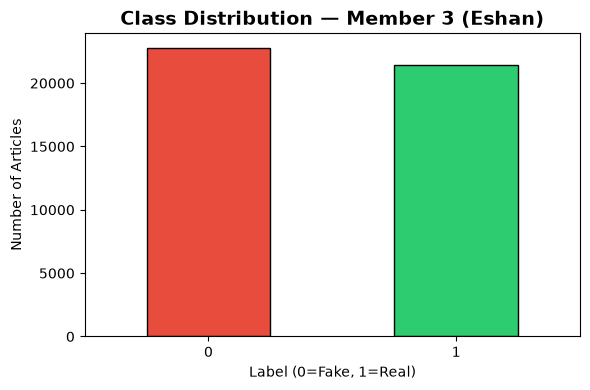

Chart saved!


In [13]:
plt.figure(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71']
df['label'].value_counts().plot(
kind='bar', color=colors, edgecolor='black')
plt.title('Class Distribution — Member 3 (Eshan)',
fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Fake, 1=Real)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('m3_class_distribution.png')
plt.show()
print("Chart saved!")
